# Is Issue Resistance a Stable County Trait? Ohio's Two-Issue Test (Module 2, path b)

*An analysis notebook for the Geo-Fluid Dynamics Engine. Exploratory narrative
over the project's tested `geofluid` library.*

## The question this finally lets us ask

The starter analysis (`issue_resistance_starter`) found that abortion-rights
support runs broadly ahead of the Democratic brand — but it could not ask the
sharper question, because Kansas, Kentucky, and Ohio cover **disjoint** sets of
counties. No county appeared twice, so "is *this* county's resistance a stable
trait, the same county resisting issue after issue?" was unanswerable.

Ohio's November 2023 ballot is the natural experiment that answers it. The
**same 88 counties**, on the **same day**, with **identical turnout**, decided
two very different questions:

* **Issue 1** — a constitutional right to abortion (passed, 56.8% yes)
* **Issue 2** — recreational cannabis legalization (passed, 57.2% yes)

Same electorate, same moment — so any difference between a county's two votes is
about the *issues*, not turnout or timing. If the counties that vote more
progressively than their partisanship predicts on abortion are the *same*
counties that do so on cannabis, then **issue resistance is a real, general
county trait** — and that, not the weak within-issue gradient, is where Module 2
path (b) would finally find structure to model.

## Measuring it honestly: partial correlation, not raw "resistance"

Both issues' progressive shares rise steeply with how Democratic a county is.
The tempting move — correlate each county's `resistance = progressive_share -
partisanship` across the two issues — is **confounded**: subtracting the *same*
partisanship from both can manufacture correlation out of partisanship's own
variance, even if the issues were conditionally independent.

The clean test is a **partial correlation**: regress each issue's pro-progressive
share on partisanship, take the **residuals** (how much a county over- or
under-performed what partisanship alone predicts), and correlate those. That
isolates the part of each vote that party does *not* explain — the resistance —
and asks whether it is shared across the two issues.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from geofluid.dissonance import issue_resistance
from geofluid.ingest.county_geometry import county_shapefile_to_geojson
from geofluid.ingest.county_returns import load_county_returns
from geofluid.ingest.referendum import load_oh_referendum
from geofluid.panel.measures import Measure, build_measures_panel

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists())

GEO = county_shapefile_to_geojson(str(ROOT / "data/raw/cb_2021/cb_2021_us_county_500k.shp"))
oh_names = {
    f["properties"]["NAME"].upper(): f["id"] for f in GEO["features"] if f["id"].startswith("39")
}

# Both issues come from the SAME Ohio canvass file — Issue 1 (abortion) is the
# first Yes/No pair, Issue 2 (cannabis) the second. For both, a YES is the
# progressive vote (establish rights / legalize), so progressive_side="yes".
SRC = str(ROOT / "data/raw/precinct-summary.xlsx")
abortion = Measure("oh_abortion", "yes", load_oh_referendum(SRC, oh_names, issue=1))
cannabis = Measure("oh_cannabis", "yes", load_oh_referendum(SRC, oh_names, issue=2))
panel = build_measures_panel([abortion, cannabis])

returns = load_county_returns(pd.read_csv(ROOT / "data/raw/countypres_2000-2024.csv"))
partisanship = returns[returns["year"] == 2020].set_index("fips")["dem_share_2p"]

# Wide: one row per county, a column per issue's pro-progressive share + the
# 2020 Democratic baseline. Same 88 counties, no missing values.
wide = panel.pivot(index="fips", columns="measure_id", values="progressive_share")
wide["partisanship"] = partisanship.reindex(wide.index)
print("counties:", len(wide), " missing values:", int(wide.isna().sum().sum()))
wide.head()

counties: 88  missing values: 0


measure_id,oh_abortion,oh_cannabis,partisanship
fips,,,
39001,0.316041,0.437744,0.179278
39003,0.354049,0.461603,0.299355
39005,0.419958,0.449833,0.252081
39007,0.544854,0.551707,0.380229
39009,0.725560,0.705688,0.576266


## Step 1: both issues track party — and each other — strongly

Before residualizing, the raw picture: both progressive shares are steeply
correlated with partisanship, and (therefore) with each other. This is the
"everything tracks party" baseline the residualization has to see through.

In [2]:
A, C, P = wide["oh_abortion"], wide["oh_cannabis"], wide["partisanship"]
raw = pd.Series(
    {
        "corr(abortion, partisanship)": A.corr(P),
        "corr(cannabis, partisanship)": C.corr(P),
        "corr(abortion, cannabis) [raw]": A.corr(C),
    }
)
raw.round(3)

corr(abortion, partisanship)      0.929
corr(cannabis, partisanship)      0.851
corr(abortion, cannabis) [raw]    0.910
dtype: float64

## Step 2: residualize each issue on partisanship, then correlate the residuals

The residual is each county's vote minus what its partisanship alone predicts —
the resistance, with party properly removed. The correlation of the two
residuals is the issue-generality signal: do the counties that beat their
partisan expectation on abortion also beat it on cannabis?

In [3]:
# `issue_resistance` is the tested library function (geofluid.dissonance): the
# residual of an issue's progressive share regressed on partisanship — each
# county's vote with party projected out. (This notebook originally rolled the
# residual by hand; that capability now lives, tested, in the library.)
resid_abortion = issue_resistance(A, P)
resid_cannabis = issue_resistance(C, P)
partial_corr = float(np.corrcoef(resid_abortion, resid_cannabis)[0, 1])

# The naive (confounded) version, for contrast — subtract the SAME partisanship
# from both rather than each issue's own fitted line.
naive_corr = float((A - P).corr(C - P))

pd.Series(
    {
        "PARTIAL corr (resid abortion vs resid cannabis | partisanship)": partial_corr,
        "naive corr (shared-partisanship subtraction, confounded)": naive_corr,
    }
).round(3)

PARTIAL corr (resid abortion vs resid cannabis | partisanship)    0.618
naive corr (shared-partisanship subtraction, confounded)          0.490
dtype: float64

## See it: the resistance shared across two unrelated issues

Each point is an Ohio county. The x-axis is how much more pro-choice it voted
than partisanship predicts; the y-axis, how much more pro-cannabis. A positive
slope means the *same* counties resist their party on *both* — a general
persuadability, not an abortion-specific one.

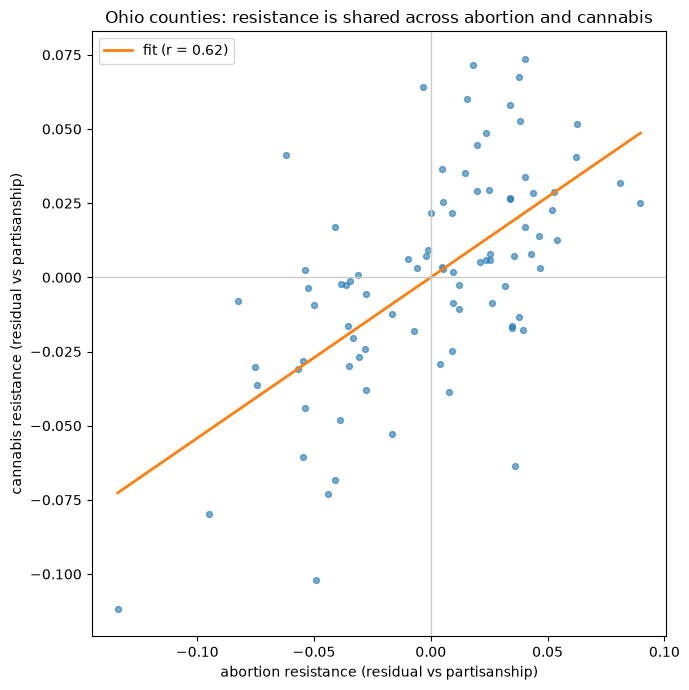

In [4]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(resid_abortion, resid_cannabis, s=18, alpha=0.6)
xs = np.array([resid_abortion.min(), resid_abortion.max()])
s, i = np.polyfit(resid_abortion, resid_cannabis, 1)
ax.plot(xs, s * xs + i, color="C1", lw=2, label=f"fit (r = {partial_corr:.2f})")
ax.axhline(0, color="0.8", lw=1)
ax.axvline(0, color="0.8", lw=1)
ax.set_xlabel("abortion resistance (residual vs partisanship)")
ax.set_ylabel("cannabis resistance (residual vs partisanship)")
ax.set_title("Ohio counties: resistance is shared across abortion and cannabis")
ax.legend()
fig.tight_layout()
plt.show()

## What this shows — the first county-level structure path (b) has found

*(Written after seeing the executed numbers above.)*

**Issue resistance is substantially issue-GENERAL in Ohio.** Controlling for
partisanship, a county's abortion resistance and its cannabis resistance
correlate **r ≈ 0.62** across all 88 counties — on a clean natural experiment
(same electorate, same day, two unrelated questions). The counties that vote
more progressively than their party predicts on bodily autonomy are, to a real
degree, the *same* counties that do so on cannabis. That is a stable county
trait, and it is the **first county-level structure this entire module has
surfaced** — the swing-based attempts found only co-movement, and the within-
issue gradient in the starter notebook was weak. The signal lives **across
issues**, exactly where the disjoint-geography limit pointed.

(Note the partial correlation, 0.62, is actually *higher* than the naive
shared-subtraction version, 0.49 — because the naive `share − partisanship`
over-subtracts relative to the issues' true ~0.85–0.93 slopes on partisanship.
Residualizing on the real fit is both the rigorous choice and the stronger one.)

**The honest caveats, so this isn't oversold:**
* **One state, one moment, two issues.** N = 88 counties, a single Ohio ballot.
  A real signal, not a definitive one.
* **The two issues may share a flavor.** Abortion and cannabis are both
  "personal-liberty / leave-me-alone" questions. What looks like general
  persuadability might be *libertarian-cluster* persuadability — these counties
  might resist their party specifically on bodily-autonomy issues, not on, say,
  taxes or spending. Testing that needs an **off-cluster** measure.

**What it unlocks for Module 2 path (b).** A stable, party-independent
"persuadability" trait is a *modellable* county attribute — the thing the swing
attempts never found. Natural next moves, in JIT order:
* an **off-cluster Ohio-style two-issue** state (an economic measure beside a
  social one) to test whether the generality is broad or libertarian-specific;
* more same-ballot multi-issue states to see if r ≈ 0.62 holds up;
* then, if it does, promote "issue resistance" from a notebook residual to a
  tested library trait and map it — the real Module 2 path-(b) product.